# AMZON DELIVERY TIME PREDICTION

This project focuses on building a Machine Learning solution to predict delivery times for e-commerce orders on Amazon.
Delivery times depend on multiple factors such as traffic conditions, weather, delivery distance, product type, and delivery agent performance.

**🎯Objectives**

->Clean and preprocess raw delivery data.

->Perform Exploratory Data Analysis (EDA) to understand key factors       affecting delivery times.

->Engineer new features (e.g., distance calculation, time-based variables).

->Train and compare multiple regression models (Linear Regression, Random Forest, Gradient Boosting, XGBoost).

->Use MLflow to track model performance and experiments.

->Develop a Streamlit application where users can input order details and get predicted delivery times.

**📊Business Motivation**

->Improve customer satisfaction with accurate delivery time estimates.

->Optimize logistics and allocate delivery resources efficiently.

->Evaluate agent performance and identify areas for improvement.

->Adapt dynamically to traffic and weather conditions for realistic predictions.

In [2]:
# Day 1 - Data Preparation, Cleaning & Feature Engineering with Quick Visualizations

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from math import radians, cos, sin, asin, sqrt

In [3]:
# 2. Load dataset
df = pd.read_csv("amazon_delivery.csv")
print(df.shape)
print(df.head())

(43739, 16)
        Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
0  ialx566343618         37           4.9       22.745049        75.892471   
1  akqg208421122         34           4.5       12.913041        77.683237   
2  njpu434582536         23           4.4       12.914264        77.678400   
3  rjto796129700         38           4.7       11.003669        76.976494   
4  zguw716275638         32           4.6       12.972793        80.249982   

   Drop_Latitude  Drop_Longitude  Order_Date Order_Time Pickup_Time  \
0      22.765049       75.912471  2022-03-19   11:30:00    11:45:00   
1      13.043041       77.813237  2022-03-25   19:45:00    19:50:00   
2      12.924264       77.688400  2022-03-19   08:30:00    08:45:00   
3      11.053669       77.026494  2022-04-05   18:00:00    18:10:00   
4      13.012793       80.289982  2022-03-26   13:30:00    13:45:00   

      Weather  Traffic      Vehicle            Area  Delivery_Time  \
0       Sunny    High 

In [4]:
# 3. Inspect data
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB
N

In [5]:
# 4. Handle missing values & duplicates
df.drop_duplicates(inplace=True)

# Clean text columns: strip whitespace, and catch the literal text "NaN"
# in any capitalization (NaN, nan, NAN, etc.) as a real missing value —
# without ever converting genuinely-missing values into the string "nan"
# by mistake.
text_cols = ["Weather", "Traffic", "Vehicle", "Area", "Category"]
for col in text_cols:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)
    df[col] = df[col].apply(lambda x: np.nan if isinstance(x, str) and x.lower() == "nan" else x)

df.fillna({
    "Weather": "Clear",
    "Traffic": "Low",
    "Vehicle": "Bike",
    "Agent_Rating": df["Agent_Rating"].mean()
}, inplace=True)

In [42]:
# 5. Encode categorical variables
cat_cols = ["Weather", "Traffic", "Vehicle", "Area", "Category"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [43]:
# 6. Feature Engineering

# --- 6.1 Distance Calculation (Haversine Formula) ---
def haversine(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Radius of earth in kilometers
    return c * r

df["Distance_km"] = df.apply(lambda row: haversine(
    row["Store_Latitude"], row["Store_Longitude"],
    row["Drop_Latitude"], row["Drop_Longitude"]), axis=1)

# --- 6.2 Time Features ---
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
# New (robust handling) ✅
df["Order_Time"] = pd.to_datetime(df["Order_Time"], errors='coerce').dt.time
df["Pickup_Time"] = pd.to_datetime(df["Pickup_Time"], errors='coerce').dt.time


df["Order_Hour"] = pd.to_datetime(df["Order_Time"], format='%H:%M:%S').dt.hour
df["Order_Weekday"] = df["Order_Date"].dt.dayofweek
df["Is_Weekend"] = df["Order_Weekday"].apply(lambda x: 1 if x>=5 else 0)

C:\Users\himan\AppData\Local\Temp\ipykernel_15568\744068212.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order_Time"] = pd.to_datetime(df["Order_Time"], errors='coerce').dt.time
C:\Users\himan\AppData\Local\Temp\ipykernel_15568\744068212.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Pickup_Time"] = pd.to_datetime(df["Pickup_Time"], errors='coerce').dt.time


In [44]:
# 7. Save cleaned dataset
df.to_csv("cleaned_amazon_delivery.csv", index=False)
print("✅ Cleaned dataset saved as cleaned_amazon_delivery.csv")

✅ Cleaned dataset saved as cleaned_amazon_delivery.csv


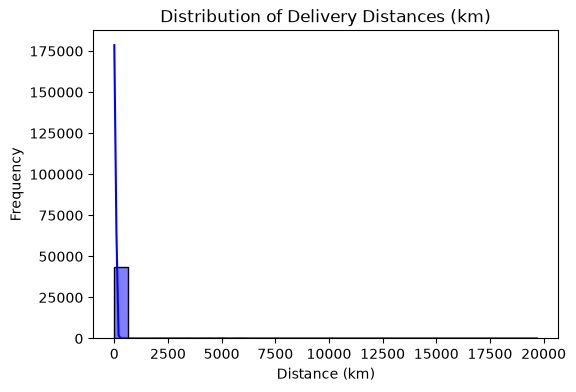

In [45]:
# ---------------------------------------------------------
# 8. Quick Sanity-Check Visualizations
# ---------------------------------------------------------

plt.figure(figsize=(6,4))
sns.histplot(df["Distance_km"], bins=30, kde=True, color="blue")
plt.title("Distribution of Delivery Distances (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.show()

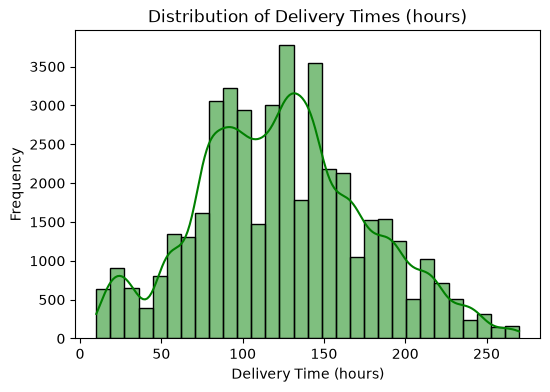

In [46]:
plt.figure(figsize=(6,4))
sns.histplot(df["Delivery_Time"], bins=30, kde=True, color="green")
plt.title("Distribution of Delivery Times (hours)")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Frequency")
plt.show()

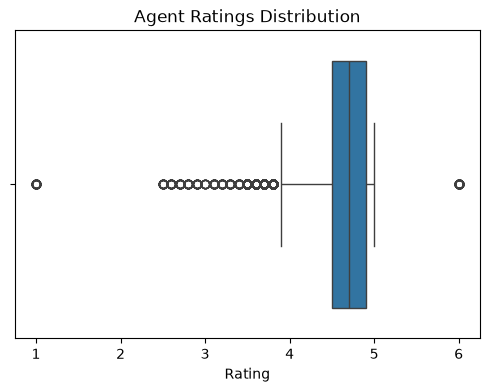

In [47]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Agent_Rating"])
plt.title("Agent Ratings Distribution")
plt.xlabel("Rating")
plt.show()

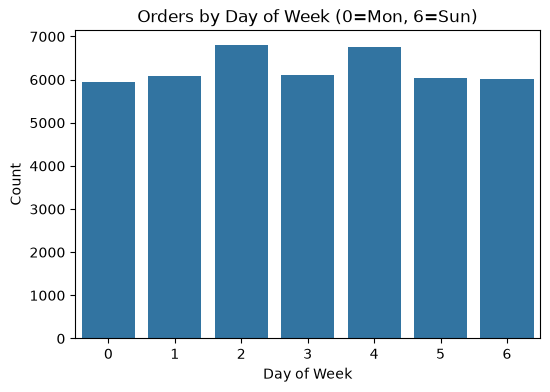

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Order_Weekday"])
plt.title("Orders by Day of Week (0=Mon, 6=Sun)")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.show()

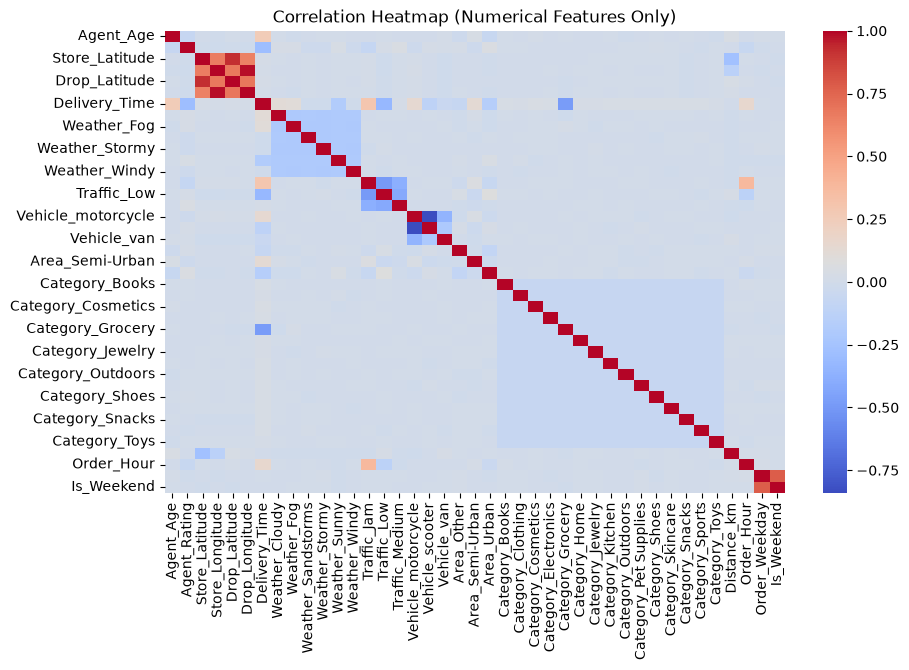

In [49]:
# Correlation heatmap (numerical features only)

numeric_df = df.select_dtypes(include=[np.number])  # only numeric columns
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

# EXPLORATORY DATA ANALYSIS

Steps:

-Load Cleaned Dataset (cleaned_amazon_delivery.csv)

-Basic Insights: shape, summary statistics, missing values check

-Delivery Time Analysis

-Distribution (histogram + KDE)

-Boxplot (outliers check)

-Impact of Factors on Delivery Time

-Traffic vs Delivery Time (boxplot / barplot)

-Weather vs Delivery Time

-Vehicle Type vs Delivery Time

-Area (Urban vs Metropolitan) vs Delivery Time

->Numerical Relationships

-Scatterplot: Distance vs Delivery Time

-Scatterplot: Agent Rating vs Delivery Time

-Correlation heatmap (numerical only)

->Agent Performance

-Delivery time distribution by Agent Age groups

-Agent Rating vs Delivery Time

-Key Insights (summary of findings to take into modeling)

In [50]:
# Day 2 - Exploratory Data Analysis (EDA)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# 1. Load cleaned dataset
df = pd.read_csv("cleaned_amazon_delivery.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (43739, 45)
        Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
0  ialx566343618         37           4.9       22.745049        75.892471   
1  akqg208421122         34           4.5       12.913041        77.683237   
2  njpu434582536         23           4.4       12.914264        77.678400   
3  rjto796129700         38           4.7       11.003669        76.976494   
4  zguw716275638         32           4.6       12.972793        80.249982   

   Drop_Latitude  Drop_Longitude  Order_Date Order_Time Pickup_Time  ...  \
0      22.765049       75.912471  2022-03-19   11:30:00    11:45:00  ...   
1      13.043041       77.813237  2022-03-25   19:45:00    19:50:00  ...   
2      12.924264       77.688400  2022-03-19   08:30:00    08:45:00  ...   
3      11.053669       77.026494  2022-04-05   18:00:00    18:10:00  ...   
4      13.012793       80.289982  2022-03-26   13:30:00    13:45:00  ...   

   Category_Pet Supplies  Category_Shoes  Category_Skin

In [52]:
# 2. Basic dataset insights
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

          Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
count  43739.000000   43739.00000    43739.000000     43739.000000   
mean      29.567137       4.63378       17.210960        70.661177   
std        5.815155       0.33451        7.764225        21.475005   
min       15.000000       1.00000      -30.902872       -88.366217   
25%       25.000000       4.50000       12.933298        73.170283   
50%       30.000000       4.70000       18.551440        75.898497   
75%       35.000000       4.90000       22.732225        78.045359   
max       50.000000       6.00000       30.914057        88.433452   

       Drop_Latitude  Drop_Longitude  Delivery_Time  Weather_Cloudy  \
count   43739.000000    43739.000000   43739.000000    43739.000000   
mean       17.459031       70.821842     124.905645        0.166625   
std         7.342950       21.153148      51.915451        0.372645   
min         0.010000        0.010000      10.000000        0.000000   
25%        12.

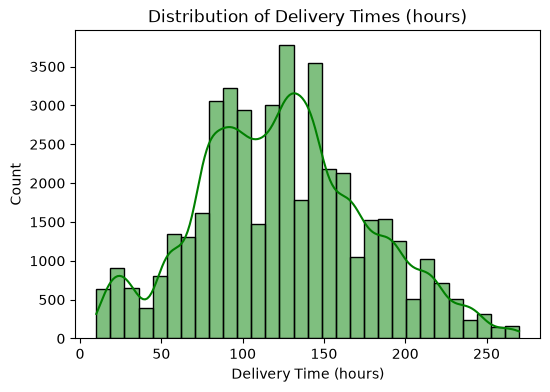

In [53]:
# 3. Delivery Time Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Delivery_Time"], bins=30, kde=True, color="green")
plt.title("Distribution of Delivery Times (hours)")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Count")
plt.show()

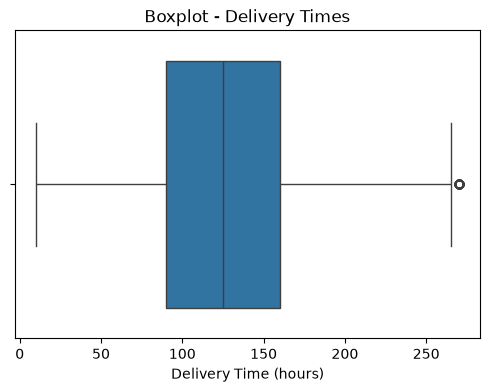

In [54]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Delivery_Time"])
plt.title("Boxplot - Delivery Times")
plt.xlabel("Delivery Time (hours)")
plt.show()

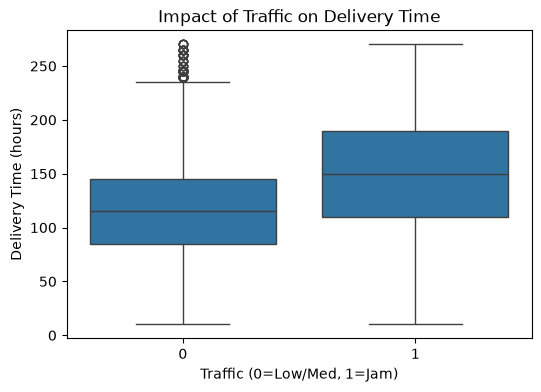

In [55]:
# 4. Impact of Factors
# 4. Impact of Categorical Factors (Dynamic Version)



plt.figure(figsize=(6,4))
sns.boxplot(x="Traffic_Jam", y="Delivery_Time", data=df)
plt.title("Impact of Traffic on Delivery Time")
plt.xlabel("Traffic (0=Low/Med, 1=Jam)")
plt.ylabel("Delivery Time (hours)")
plt.show()

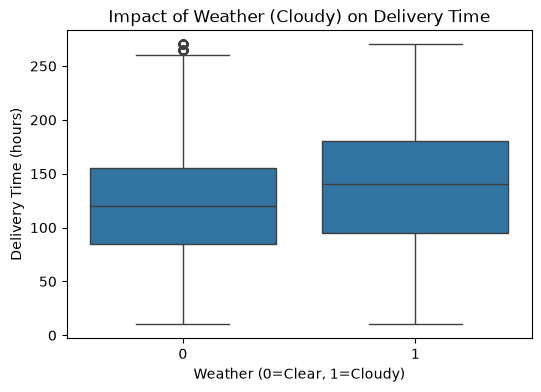

In [56]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Weather_Cloudy", y="Delivery_Time", data=df)
plt.title("Impact of Weather (Cloudy) on Delivery Time")
plt.xlabel("Weather (0=Clear, 1=Cloudy)")
plt.ylabel("Delivery Time (hours)")
plt.show()

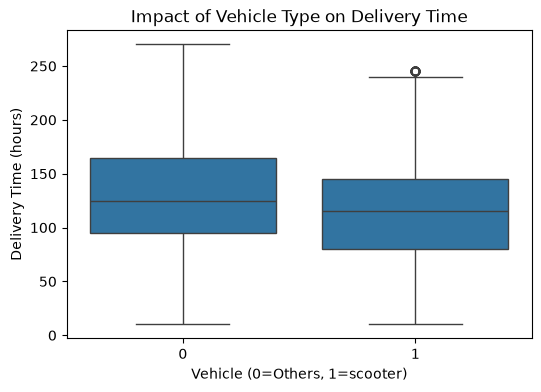

In [57]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Vehicle_scooter", y="Delivery_Time", data=df)
plt.title("Impact of Vehicle Type on Delivery Time")
plt.xlabel("Vehicle (0=Others, 1=scooter)")
plt.ylabel("Delivery Time (hours)")
plt.show()

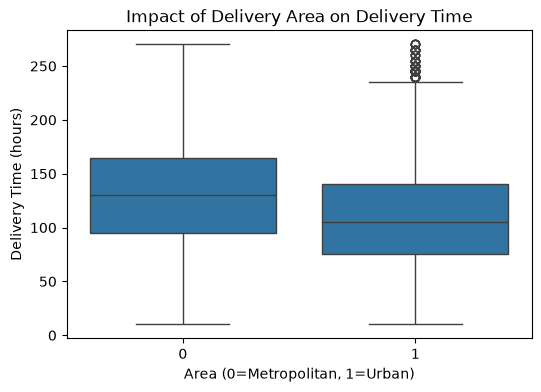

In [58]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Area_Urban", y="Delivery_Time", data=df)
plt.title("Impact of Delivery Area on Delivery Time")
plt.xlabel("Area (0=Metropolitan, 1=Urban)")
plt.ylabel("Delivery Time (hours)")
plt.show()

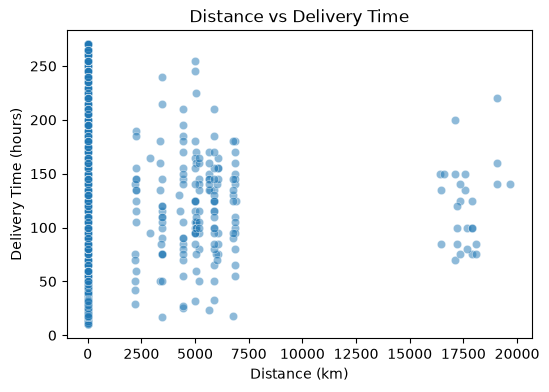

In [59]:
# 5. Numerical Relationships
plt.figure(figsize=(6,4))
sns.scatterplot(x="Distance_km", y="Delivery_Time", data=df, alpha=0.5)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (hours)")
plt.show()

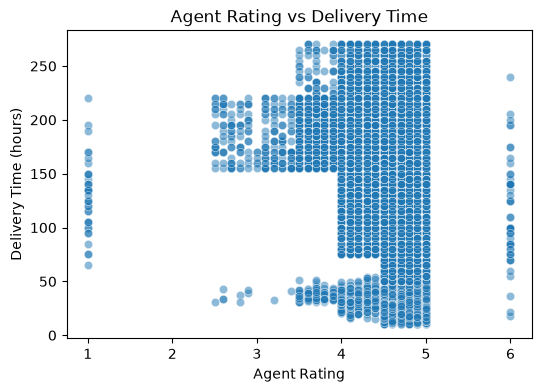

In [60]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Agent_Rating", y="Delivery_Time", data=df, alpha=0.5)
plt.title("Agent Rating vs Delivery Time")
plt.xlabel("Agent Rating")
plt.ylabel("Delivery Time (hours)")
plt.show()

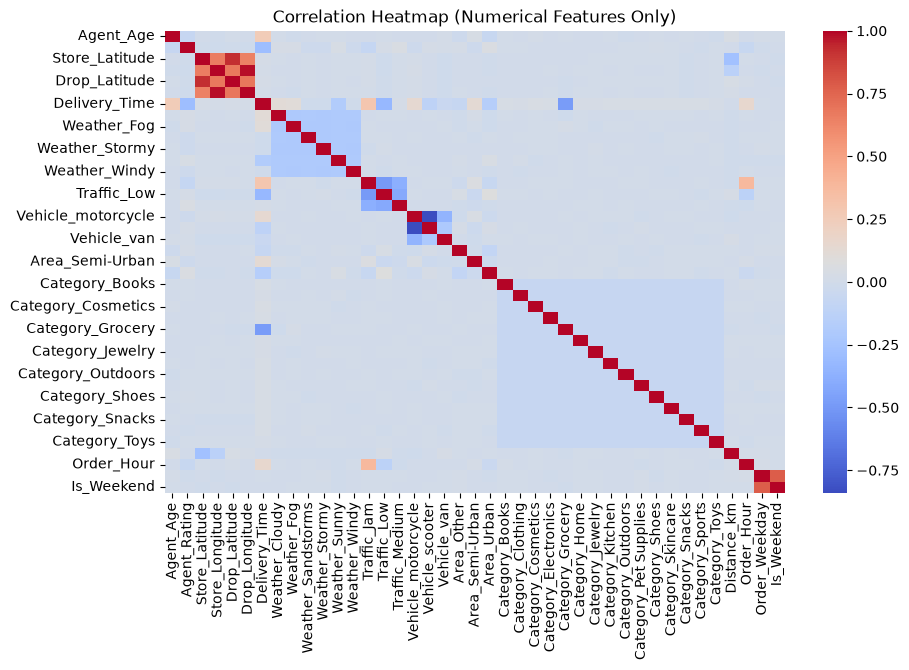

In [61]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

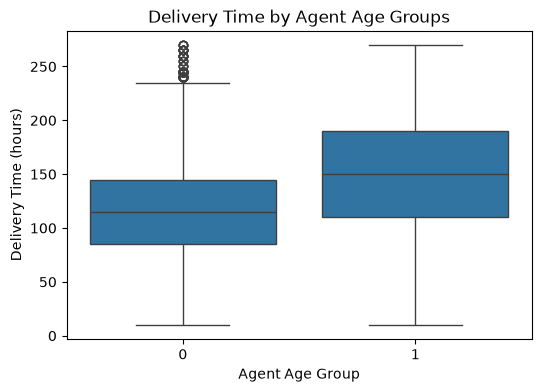

✅ EDA Completed. Key insights can be summarized after reviewing plots.


In [62]:
# 6. Agent Performance
df["Agent_Age_Group"] = pd.cut(df["Agent_Age"], bins=[18,25,35,45,60], labels=["18-25","26-35","36-45","46-60"])
plt.figure(figsize=(6,4))
sns.boxplot(x="Traffic_Jam", y="Delivery_Time", data=df)


plt.title("Delivery Time by Agent Age Groups")
plt.xlabel("Agent Age Group")
plt.ylabel("Delivery Time (hours)")
plt.show()
# 7. Key Insights (to print later)
print("✅ EDA Completed. Key insights can be summarized after reviewing plots.")

In [6]:
print([col for col in df.columns if any(x in col for x in ["Traffic","Weather","Vehicle","Area"])])


['Weather', 'Traffic', 'Vehicle', 'Area']


**🧠 Phase 3 – Model Training + MLflow Tracking**

We'll:

- Split data into features/target
- Train multiple regression models (Linear Regression, Random Forest, Gradient Boosting) inside `Pipeline`s with a `SimpleImputer` step, so missing values are handled automatically
- Evaluate using RMSE, MAE, R²
- Track results with MLflow (metrics + params; model artifact logging is optional and wrapped safely so it can never break the run)
- Save the best model locally for the Streamlit app

**Note:** Run `pip install mlflow` once from your terminal (not inside the notebook) before running this section.

In [64]:
# Day 3 - Model Training, Evaluation & MLflow Tracking

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn
import pickle
import sklearn

print(f"scikit-learn version: {sklearn.__version__}")
print("⚠️ This version is what best_delivery_model.pkl will be saved with.")
print("   The app.py environment MUST use this same scikit-learn version to load it correctly.")

scikit-learn version: 1.8.0
⚠️ This version is what best_delivery_model.pkl will be saved with.
   The app.py environment MUST use this same scikit-learn version to load it correctly.


In [65]:
# ===============================================================
# 1) Load Cleaned Dataset
# ===============================================================
df = pd.read_csv("cleaned_amazon_delivery.csv")
print("Shape:", df.shape)

Shape: (43739, 45)


In [66]:
# Define features and target
X = df.drop(columns=["Delivery_Time", "Order_ID"], errors='ignore')
y = df["Delivery_Time"]

# Drop date/time columns not needed for regression (already extracted into
# Order_Hour, Order_Weekday, Is_Weekend) and drop raw GPS coordinates
# (already captured usefully via the engineered Distance_km feature —
# keeping raw lat/long causes the model to overfit to specific locations
# and breaks badly on any coordinates outside the training data, e.g.
# placeholder 0.0 values from the Streamlit app).
X = X.drop(columns=[
    'Order_Date', 'Order_Time', 'Pickup_Time',
    'Store_Latitude', 'Store_Longitude',
    'Drop_Latitude', 'Drop_Longitude'
], errors='ignore')

# Keep only numeric columns (categoricals were already one-hot encoded in Day 1)
X = X.select_dtypes(include=[np.number])

print("✅ Feature columns:", X.columns.tolist())
print("✅ Feature matrix shape:", X.shape)

✅ Feature columns: ['Agent_Age', 'Agent_Rating', 'Weather_Cloudy', 'Weather_Fog', 'Weather_Sandstorms', 'Weather_Stormy', 'Weather_Sunny', 'Weather_Windy', 'Traffic_Jam', 'Traffic_Low', 'Traffic_Medium', 'Vehicle_motorcycle', 'Vehicle_scooter', 'Vehicle_van', 'Area_Other', 'Area_Semi-Urban', 'Area_Urban', 'Category_Books', 'Category_Clothing', 'Category_Cosmetics', 'Category_Electronics', 'Category_Grocery', 'Category_Home', 'Category_Jewelry', 'Category_Kitchen', 'Category_Outdoors', 'Category_Pet Supplies', 'Category_Shoes', 'Category_Skincare', 'Category_Snacks', 'Category_Sports', 'Category_Toys', 'Distance_km', 'Order_Hour', 'Order_Weekday', 'Is_Weekend']
✅ Feature matrix shape: (43739, 36)


In [67]:
# ===============================================================
# 2) Handle Missing Values
# ===============================================================
# Drop only rows that are entirely empty; remaining NaNs are handled
# by the SimpleImputer step inside each model pipeline below.
X = X.dropna(how='all')
y = y.loc[X.index]

print("🔍 Total missing values before imputation:", X.isna().sum().sum())

🔍 Total missing values before imputation: 91


In [68]:
# ===============================================================
# 3) Train-Test Split
# ===============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✅ Train size: {X_train.shape}, Test size: {X_test.shape}")

✅ Train size: (34991, 36), Test size: (8748, 36)


In [69]:
# ===============================================================
# 4) Define Models with Imputation Pipelines
# ===============================================================
models = {
    "Linear Regression": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
    ])
}

In [70]:
# ===============================================================
# 5) Train, Evaluate & Track with MLflow
# ===============================================================
mlflow.set_experiment("Amazon_Delivery_Time_Prediction")

best_model = None
best_rmse = float("inf")
results = []

for name, pipeline in models.items():
    with mlflow.start_run(run_name=name):
        # Train model
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)

        # Evaluate
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        # Cross-validation RMSE
        cv_rmse = np.mean(np.sqrt(-cross_val_score(
            pipeline, X_train, y_train,
            scoring='neg_mean_squared_error', cv=5
        )))

        # Log params and metrics (always safe)
        model_step = pipeline.named_steps['model']
        mlflow.log_params(model_step.get_params())
        mlflow.log_metrics({
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "CV_RMSE": cv_rmse
        })

        # Log the model artifact to MLflow.
        # This step is optional (only needed if you want to load models back
        # via MLflow's registry) and wrapped in try/except so a strict
        # serialization check in newer skops/mlflow versions can never
        # crash the training run.
        try:
            mlflow.sklearn.log_model(
                pipeline,
                name=name.replace(" ", "_") + "_pipeline"
            )
        except Exception as e:
            print(f"⚠️ MLflow model logging skipped for {name} ({type(e).__name__}). "
                  f"Metrics were still logged successfully.")

        print(f"\n📊 {name} Results:")
        print(f"MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f} | CV_RMSE: {cv_rmse:.3f}")

        results.append({
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "CV_RMSE": cv_rmse
        })

        if rmse < best_rmse:
            best_rmse = rmse
            best_model = pipeline

⚠️ MLflow model logging skipped for Linear Regression (MlflowException). Metrics were still logged successfully.

📊 Linear Regression Results:
MAE: 26.115 | RMSE: 33.169 | R²: 0.587 | CV_RMSE: 33.394
⚠️ MLflow model logging skipped for Random Forest (MlflowException). Metrics were still logged successfully.

📊 Random Forest Results:
MAE: 17.277 | RMSE: 22.562 | R²: 0.809 | CV_RMSE: 22.885
⚠️ MLflow model logging skipped for Gradient Boosting (MlflowException). Metrics were still logged successfully.

📊 Gradient Boosting Results:
MAE: 19.185 | RMSE: 24.484 | R²: 0.775 | CV_RMSE: 24.784


In [71]:
# ===============================================================
# 6) Save Best Model & Results
# ===============================================================
pd.DataFrame(results).to_csv("model_results.csv", index=False)
print("✅ All model results saved to 'model_results.csv'")

with open("best_delivery_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"🏆 Best model saved as 'best_delivery_model.pkl' (RMSE: {best_rmse:.3f})")
print(f"   Trained and saved with scikit-learn {sklearn.__version__}")
print("\n🎯 Model training and MLflow tracking complete!")

✅ All model results saved to 'model_results.csv'
🏆 Best model saved as 'best_delivery_model.pkl' (RMSE: 22.562)
   Trained and saved with scikit-learn 1.8.0

🎯 Model training and MLflow tracking complete!


## ✅ Summary (for interview walkthrough)

- **Pipeline:** Data cleaning → feature engineering (Haversine distance, time features, one-hot encoding) → EDA → model comparison → best-model selection → Streamlit deployment.
- **Models compared:** Linear Regression, Random Forest, Gradient Boosting — each wrapped in a `Pipeline` with a `SimpleImputer`, so the same object handles missing values, training, and inference consistently (no separate imputation step to keep in sync with `app.py`).
- **Model selection:** best of the three by test-set RMSE, logged and compared via MLflow.
- **Reproducibility note:** the saved `.pkl` is tied to the scikit-learn version active when this notebook is run. If `app.py` ever throws an `InconsistentVersionWarning` or `AttributeError` on load, it means the app's environment and this notebook's environment have drifted apart — rerun this notebook in the *same* Python environment used to launch Streamlit to regenerate a matching pickle (see `requirements.txt` for the pinned versions this project expects).

- **Known limitation — traffic ordering:** Traffic level correlates strongly 
  with delivery time on average across the dataset (Low ≈101 min → Medium 
  ≈127 min → High ≈129 min → Jam ≈148 min). However, the Random Forest model 
  doesn't guarantee this ordering holds for every individual input combination 
  — tree ensembles learn feature interactions rather than enforcing a strict 
  monotonic relationship. For a small number of specific input combinations, 
  changing traffic level alone can produce a counter-intuitive prediction. 
  A next step would be applying monotonic constraints (e.g. via 
  HistGradientBoostingRegressor's `monotonic_cst` parameter) to guarantee 
  traffic always pushes predicted time in the correct direction.